In [1]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from google.colab import files

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [2]:

# 1. Upload the zip file directly to Colab
print("Please upload your 'example_dataset.zip' file")
uploaded = files.upload()

# 2. Unzip the dataset
zip_filename = next(iter(uploaded))
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall()

Please upload your 'example_dataset.zip' file


Saving example_dataset.zip to example_dataset.zip


In [3]:
# Constants (paths relative to unzipped location)
DATASET_PATH = "example_dataset"
TRAIN_CSV = os.path.join(DATASET_PATH, "train.csv")
TEST_CSV = os.path.join(DATASET_PATH, "test.csv")
IMAGE_SIZE = (64, 64)  # Reduced size for lighter model
BATCH_SIZE = 32
EPOCHS = 25  # With early stopping, we may not need all epochs

# 3. Load the CSV data
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)


In [4]:
# Function to load images and target x only
def load_images_and_target(df):
    images = []
    targets = []

    for _, row in df.iterrows():
        img_path = row['image_path']
        # Handle path formatting (remove dataset prefix if present)
        img_path = img_path.replace('example_dataset/', '')
        img_path = os.path.join(DATASET_PATH, img_path)

        try:
            img = load_img(img_path, target_size=IMAGE_SIZE, color_mode='rgb')
            #img_array = img_to_array(img) / 255.0  # Normalize to [0,1]

            images.append(img)
            targets.append(row['y'])  # Only target x
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            continue

    return np.array(images), np.array(targets)


In [5]:
# 4. Load training and test data
print("Loading training data...")
X_train, y_train = load_images_and_target(train_df)
print("Loading test data...")
X_test, y_test = load_images_and_target(test_df)

# Print dataset information
print(f"\nTraining data shape: {X_train.shape}")
print(f"Training targets shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test targets shape: {y_test.shape}")


Loading training data...
Loading test data...

Training data shape: (1000, 64, 64, 3)
Training targets shape: (1000,)
Test data shape: (100, 64, 64, 3)
Test targets shape: (100,)


In [6]:
# 5. Very Lightweight CNN Model Architecture
def create_lightweight_model(input_shape):
    model = Sequential([
        # First conv block
        Conv2D(8, (3, 3), activation='relu', input_shape=input_shape, kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Second conv block
        Conv2D(16, (3, 3), activation='relu', kernel_regularizer=l2(0.001)),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        # Flatten and dense layers
        Flatten(),
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
        Dropout(0.4),

        # Output layer (single value for regression)
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=0.001),
                loss='mse',
                metrics=['mae'])

    return model

In [8]:
# Create and show model summary
model = create_lightweight_model(X_train.shape[1:])
print("\nModel Summary:")
model.summary()



Model Summary:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       100,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,809 (397.69 KB)

 Trainable params: 101,809 (397.69 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# 6. Training with Early Stopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\nTraining model...")
history = model.fit(X_train, y_train,
                  batch_size=BATCH_SIZE,
                  epochs=EPOCHS,
                  validation_data=(X_test, y_test),
                  callbacks=[early_stop],
                  verbose=1)


Training model...
Epoch 1/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 477.1040 - mae: 15.5982 - val_loss: 2.1721 - val_mae: 0.9928
Epoch 2/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - loss: 10.7073 - mae: 1.9116 - val_loss: 0.4703 - val_mae: 0.5275
Epoch 3/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.7693 - mae: 0.9192 - val_loss: 0.4106 - val_mae: 0.4983
Epoch 4/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.2723 - mae: 0.7686 - val_loss: 0.4069 - val_mae: 0.4998
Epoch 5/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.9894 - mae: 0.6697 - val_loss: 0.4229 - val_mae: 0.5162
Epoch 6/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 1.0495 - mae: 0.6455 - val_loss: 0.4238 - val_mae: 0.5183
Epoch 7/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.7710 - mae: 0.6129 - val_loss: 0.4185 - val_mae: 0.5119
Epoch 8/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 0.6882 - mae: 0.5791 - val_loss: 0.4109 - val_mae: 0.5045
Epoch 9/25
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [11]:

# 7. Evaluation Function
def evaluate_model(model, X, y_true, set_name="Test"):
    y_pred = model.predict(X).flatten()

    metrics = {
        'MAE': mean_absolute_error(y_true, y_pred),
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

    print(f"\n{set_name} Set Metrics:")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    return y_pred, metrics

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step

Train Set Metrics:
MAE: 0.4670
MSE: 0.2743
RMSE: 0.5238
R2: 0.4762
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

Test Set Metrics:
MAE: 0.4453
MSE: 0.2582
RMSE: 0.5081
R2: 0.4739


Text(0, 0.5, 'Predictions')

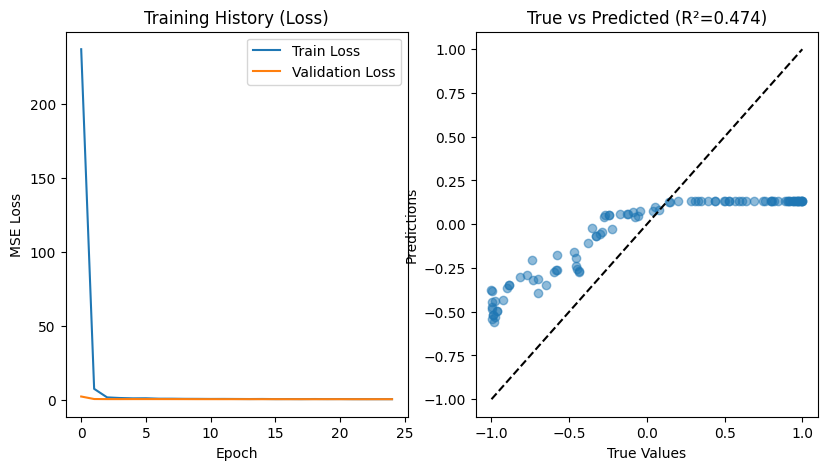

In [12]:
# Evaluate on both sets
train_pred, train_metrics = evaluate_model(model, X_train, y_train, "Train")
test_pred, test_metrics = evaluate_model(model, X_test, y_test, "Test")

# 8. Visualization
plt.figure(figsize=(15, 5))

# Training history
plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training History (Loss)')
plt.ylabel('MSE Loss')
plt.xlabel('Epoch')
plt.legend()

# Scatter plot
plt.subplot(1, 3, 2)
plt.scatter(y_test, test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')
plt.title(f'True vs Predicted (R²={test_metrics["R2"]:.3f})')
plt.xlabel('True Values')
plt.ylabel('Predictions')


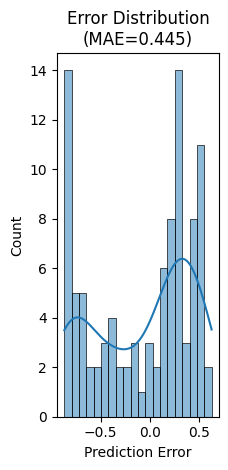

In [13]:
# Error histogram
plt.subplot(1, 3, 3)
errors = test_pred - y_test
sns.histplot(errors, kde=True, bins=20)
plt.title(f'Error Distribution\n(MAE={test_metrics["MAE"]:.3f})')
plt.xlabel('Prediction Error')

plt.tight_layout()
plt.show()